<a href="https://colab.research.google.com/github/ErbolTakhirov/Learning-notebooks/blob/main/ML/classification/classification_lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Classification

Продолжим изучать задачу классификации и метрики оценки качества классификации.

Постановка проблематики:

* Рассмотрим ситуацию "перекрывания" классов, то есть когда для одинакового признакового описания имеются метки обоих классов.

* Рассмотрим основные способы оценки качества классификации.


Решим пока эту задачу без использования вероятностного подхода.

## Данные

Возьмем популярный датасет "Ирисы Фишера" и отберем из него 2 класса для эксперимента в рамках бинарной классификации и всего 2 количественных признака.

In [33]:
df = sns.load_dataset('iris')

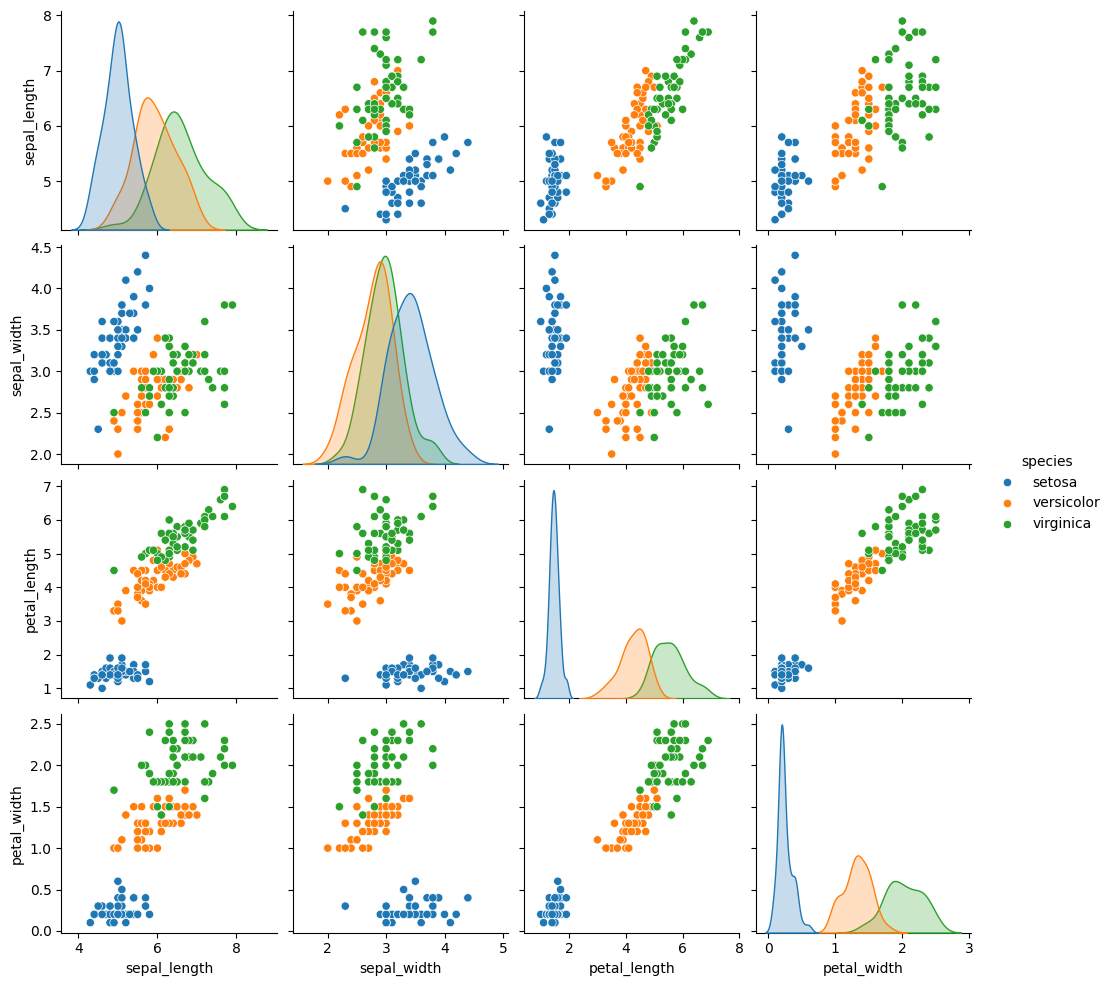

In [34]:
sns.pairplot(data=df, hue='species')

In [35]:
data = df.loc[df.species != 'setosa', ['petal_length', 'petal_width', 'species']].replace({'versicolor':1, 'virginica':-1})
data

/tmp/ipython-input-2775132455.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = df.loc[df.species != 'setosa', ['petal_length', 'petal_width', 'species']].replace({'versicolor':1, 'virginica':-1})


,petal_length,petal_width,species
50,4.7,1.4,1
51,4.5,1.5,1
52,4.9,1.5,1
53,4.0,1.3,1
54,4.6,1.5,1
...,...,...,...
145,5.2,2.3,-1
146,5.0,1.9,-1
147,5.2,2.0,-1
148,5.4,2.3,-1


Изучим распределения. Какая потенциальная проблема нас ожидает?

<Axes: xlabel='petal_width', ylabel='Density'>

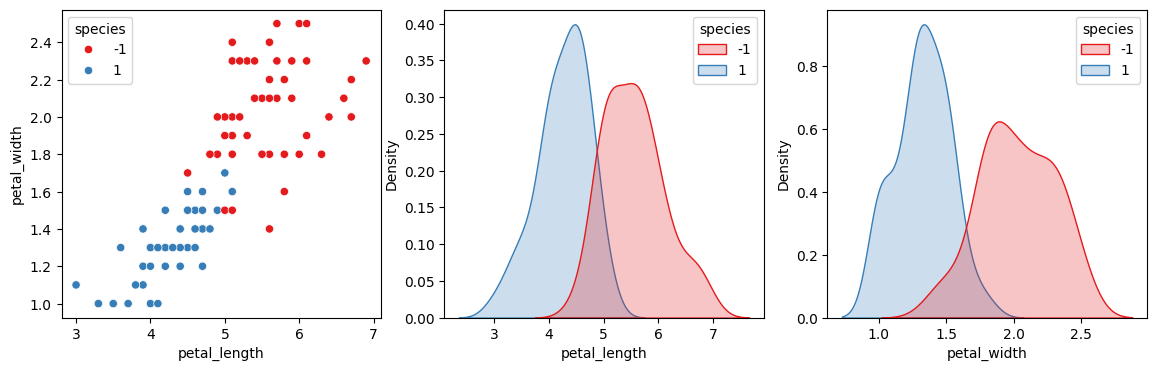

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
sns.scatterplot(data=data, x='petal_length', y='petal_width', hue='species', ax=ax[0], palette='Set1')
sns.kdeplot(data=data, x='petal_length',hue='species', ax=ax[1], palette='Set1', fill=True)
sns.kdeplot(data=data, x='petal_width',hue='species', ax=ax[2], palette='Set1', fill=True)

## Алгоритм

Перед нами стоит задача использования алгоритма классификации. Но нам необходимо определиться с функцией потерь, по которой мы будем оптимизировать алгоритм.

Полученный прежде функционал качества алгоритма на одном наблюдении $$L(M) = [M < 0]$$

является пороговой функцией, поэтому оптимизировать алгоритм на нем будет неудобно. Об этом мы подробно говорили в прошлом семинаре. Однако существует множество подходов гладкой аппроксимации порогового функционала.

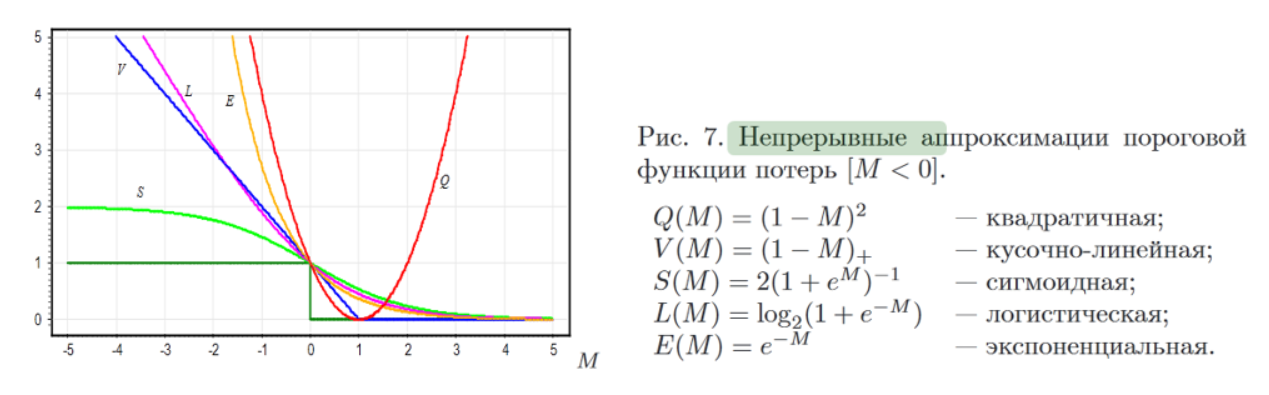

Надеюсь, нокто не забыл, что такое `Margin`:

$$M_i = y_i(x^T_i w + w_0)$$

## SGDClassifier

Объект [SGDClissifier](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html) позволяет обучать линейные модели классификации с помощью стохастического градиентного спуска.

Давайте изучим документацию!

In [37]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split

In [38]:
X = data.drop('species', axis=1)
y = data.species
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.1)

In [39]:
sgd = SGDClassifier(loss="perceptron", penalty=None, fit_intercept=True)
sgd.fit(X, y)
y_pred=sgd.predict(X)

In [40]:
y.values

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [41]:
y_pred

array([ 1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [42]:
sgd.coef_, sgd.intercept_

(array([[ -16.77251367, -165.0143267 ]]), array([337.42502876]))

In [43]:
xx = np.array([3, 7])
yy = -sgd.coef_[0][0] / sgd.coef_[0][1] * xx - sgd.intercept_/sgd.coef_[0][1]

Text(0.5, 1.0, 'SGD Classifier')

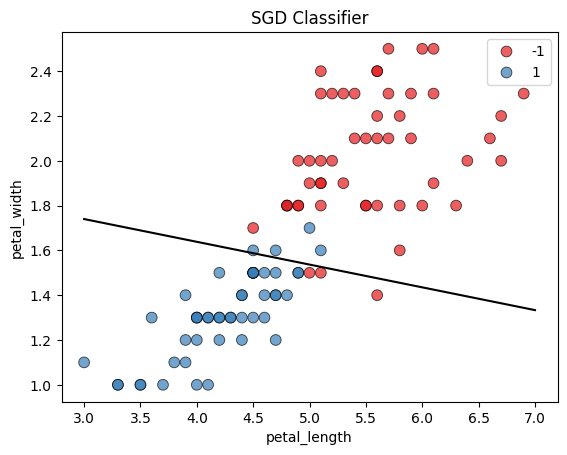

In [44]:
sns.scatterplot(data=data, x='petal_length', y='petal_width', hue='species', palette='Set1', alpha=.7, s=60, edgecolor='black')
sns.lineplot(x=xx, y=yy, color='black').set_title('SGD Classifier')

# Task

Проведите ряд экспериментов, используя другие гиперпараметры.. Возможно, иначе себя поведет модель с использованием масштабирования и регуляризации.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.1)

In [46]:
sgd = SGDClassifier(loss="perceptron", penalty=None, fit_intercept=True)
sgd.fit(X_train, y_train)
y_pred=sgd.predict(X_test)

In [47]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

In [48]:
model = SGDRegressor(loss='huber')

In [49]:
param_grid = {'penalty': ['l2', 'l1'],
              'alpha': np.logspace(-5, 1, 15),
              'eta0': [.005, .01, .15],
              'power_t': [.15, .2, .3],
               'epsilon': [100, 200, 400]}

In [50]:
%%time
searcher = GridSearchCV(model, param_grid, scoring="neg_root_mean_squared_error", cv=4, verbose=3, n_jobs=10)
searcher.fit(X_train, y_train)

Fitting 4 folds for each of 810 candidates, totalling 3240 fits
CPU times: user 1.92 s, sys: 42.9 ms, total: 1.96 s
Wall time: 17.3 s


GridSearchCV(cv=4, estimator=SGDRegressor(loss='huber'), n_jobs=10,
             param_grid={'alpha': array([1.00000000e-05, 2.68269580e-05, 7.19685673e-05, 1.93069773e-04,
       5.17947468e-04, 1.38949549e-03, 3.72759372e-03, 1.00000000e-02,
       2.68269580e-02, 7.19685673e-02, 1.93069773e-01, 5.17947468e-01,
       1.38949549e+00, 3.72759372e+00, 1.00000000e+01]),
                         'epsilon': [100, 200, 400],
                         'eta0': [0.005, 0.01, 0.15], 'penalty': ['l2', 'l1'],
                         'power_t': [0.15, 0.2, 0.3]},
             scoring='neg_root_mean_squared_error', verbose=3)

In [51]:
print(f'Accuracy: {sum([y_pred == y_test])/ len(y_test)}')

Accuracy: 118    0.1
121    0.1
133    0.0
128    0.1
55     0.1
117    0.1
103    0.1
147    0.1
126    0.1
81     0.1
Name: species, dtype: float64


In [52]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred, y_test)

0.9

In [53]:
xx = np.array([3, 7])
yy = -sgd.coef_[0][0] / sgd.coef_[0][1] * xx - sgd.intercept_/sgd.coef_[0][1]

Text(0.5, 1.0, 'SGD Classifier')

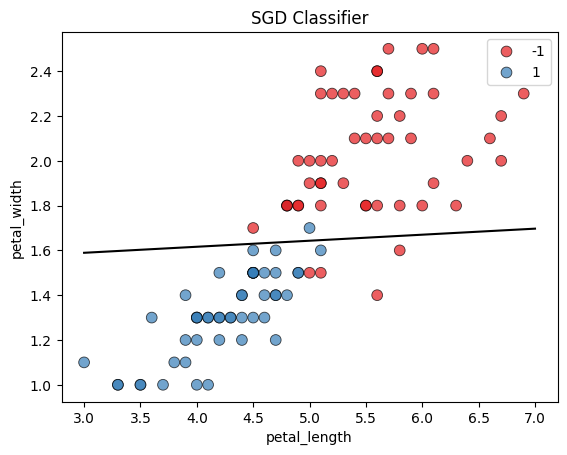

In [54]:
sns.scatterplot(data=data, x='petal_length', y='petal_width', hue='species', palette='Set1', alpha=.7, s=60, edgecolor='black')
sns.lineplot(x=xx, y=yy, color='black').set_title('SGD Classifier')

# Метрики оценки модели


## Confusion_matrix

Для оценки качества классификации также рассматривают [матрицу ошибок](http://en.wikipedia.org/wiki/Confusion_matrix): строчки соответствуют прогнозу модели, столбцы — истинным ответам, ячейки содержат число примеров тестовой выборки.

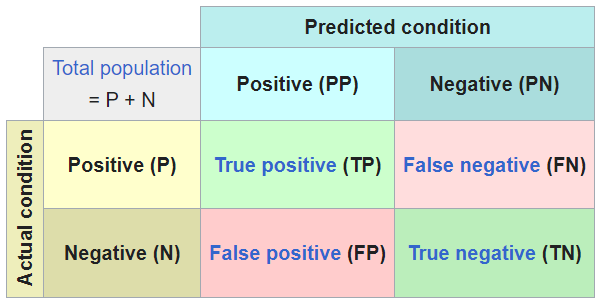

Диагональ матрицы ошибок содержит правильно классифицированные положительные (TP) и отрицательные (TN) примеры.

* False Positive (FP) — ошибки I рода (ложное срабатывание, положили в спам хорошее письмо)
* False Negative (FN) — ошибки II рода (не отфильтровали спам).

Ошибки I и II рода могут иметь различную стоимость.

Часто рассматриваются следующие метрики качества бинарной классификации:
  - Доля правильных ответов (Accuracy):
  $$accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
  - Точность/precision (доля действительно положительных объектов среди объектов, выделенных алгоритмом):
  $$precision = \frac{TP}{TP + FP}$$
  - Полнота/recall (доля выделенных алгоритмом объектов среди всех положительных объектов выборки):
  $$recall = \frac{TP}{TP + FN}$$
  - $F_1$-мера (среднее гармоническое между точностью и полнотой)
  $$F_1 = \frac{2 \cdot Precision \cdot Recall}{Precision + Recall}$$

In [55]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

In [56]:
accuracy_score(y_test, y_pred)

0.9

In [57]:
confusion_matrix(y_test, y_pred)

array([[7, 1],
       [0, 2]])

In [58]:
precision_score(y_test, y_pred, pos_label=1)

0.6666666666666666

# New DataSet


In [71]:
!wget 'https://www.dropbox.com/scl/fi/agnovv5qswaogv8et3ubl/rice_dataset.zip?rlkey=glr683n55s1m0zqmbhqyuo58a&st=nmr34prg&dl=0' -O 'rice_dataset.zip'
!apt install -y unzip
!unzip rice_dataset.zip
rice = pd.read_csv('/content/riceClassification.csv').drop('id', axis=1)

--2025-10-18 05:14:33--  https://www.dropbox.com/scl/fi/agnovv5qswaogv8et3ubl/rice_dataset.zip?rlkey=glr683n55s1m0zqmbhqyuo58a&st=nmr34prg&dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6030:18::a27d:5012
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucf0b86849de773d80b5e844788a.dl.dropboxusercontent.com/cd/0/inline/CzfKKac2G6wQ2Hd4OrcxaojFwOzHYAR9NnPN3qtcTOVP9duqxE8SCElJf_Jn4N_8tHNBGI4r-20rppuRiXMyp9KzosQ7ve8ov8qBqeONeOoOHMBsR6hutNbif4QhNX0PAYsIRnC3WtITmVj4lsV4CwRt/file# [following]
--2025-10-18 05:14:34--  https://ucf0b86849de773d80b5e844788a.dl.dropboxusercontent.com/cd/0/inline/CzfKKac2G6wQ2Hd4OrcxaojFwOzHYAR9NnPN3qtcTOVP9duqxE8SCElJf_Jn4N_8tHNBGI4r-20rppuRiXMyp9KzosQ7ve8ov8qBqeONeOoOHMBsR6hutNbif4QhNX0PAYsIRnC3WtITmVj4lsV4CwRt/file
Resolving ucf0b86849de773d80b5e844788a.dl.dropboxusercontent.com (ucf0b86849de773d80b5e844788a.dl.dropboxusercontent.com)..

In [60]:
rice

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1
...,...,...,...,...,...,...,...,...,...,...,...
18180,5853,148.624571,51.029281,0.939210,6008,86.326537,0.498594,332.960,0.663444,2.912535,0
18181,7585,169.593996,58.141659,0.939398,7806,98.272692,0.647461,385.506,0.641362,2.916910,0
18182,6365,154.777085,52.908085,0.939760,6531,90.023162,0.561287,342.253,0.682832,2.925396,0
18183,5960,151.397924,51.474600,0.940427,6189,87.112041,0.492399,343.371,0.635227,2.941216,0


In [72]:
y = rice.Class
X = rice.drop('Class', axis = 1)

In [73]:
X

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000
...,...,...,...,...,...,...,...,...,...,...
18180,5853,148.624571,51.029281,0.939210,6008,86.326537,0.498594,332.960,0.663444,2.912535
18181,7585,169.593996,58.141659,0.939398,7806,98.272692,0.647461,385.506,0.641362,2.916910
18182,6365,154.777085,52.908085,0.939760,6531,90.023162,0.561287,342.253,0.682832,2.925396
18183,5960,151.397924,51.474600,0.940427,6189,87.112041,0.492399,343.371,0.635227,2.941216


In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


column_transformer = ColumnTransformer([
    ('scaling', StandardScaler())
])

base_pipeline = Pipeline([
    ('enc_and_scaling', column_transformer),
    ('regression', Ridge())
])


model = base_pipeline.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("TEST R2:\t %.4f" % r2_score(y_test, y_pred))
print("TEST MAPE:\t %.4f" % mean_absolute_percentage_error(y_test, y_pred))
print('-----------------')
print("TEST RMSE:\t %.4f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("TEST MAE:\t %.4f" % mean_absolute_error(y_test, y_pred))

In [79]:
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

sgd_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SGDClassifier(loss='log_loss', max_iter=1000, random_state=42))
])

sgd_pipeline.fit(X_train, y_train)
y_pred_sgd = sgd_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_sgd))
print("F1-score:", f1_score(y_test, y_pred_sgd))

Accuracy: 0.9895518284300248
F1-score: 0.9905425584868094
